In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None)
from datetime import datetime

1.Φορτώνω τα δεδομένα και δημιουργώ ενα copy για να μην τα επιρρεάσω

In [6]:
#original data
food=pd.read_csv(r"wfpvam_foodprices.csv",encoding='latin-1',low_memory=False)
#copy
f = food.copy()

2.Στο νεο dataframe αλλαζω τα ονοματα για να μην εχω προβλημα με τα κενα

In [7]:
f.set_axis(['id','country', 'adm1_id', 'city','market_id','market','com_id','commodity','cur_id','cur_name','cat_id','cat_name','um_id','um_name','month','year','price','mp_commoditysource'], axis='columns',inplace=True)

3.Δημιουργώ μια στήλη με ημέρα '28' και κατοπιν μια νεα στηλη με συγκεκριμένη ημερομηνία για να μπορω να κανω plot ανα μηνα

In [8]:
#f['day']=28
#f['myDt'] = f.apply(lambda row: datetime.strptime(f"{int(row.year)}-{int(row.month)}-{int(row.day)}", '%Y-%m-%d'), axis=1)

4.Τσεκάρω τα βασικά στοιχεία του dataframe

In [9]:
#f.head()
f.tail()

,id,country,adm1_id,city,market_id,market,com_id,commodity,cur_id,cur_name,cat_id,cat_name,um_id,um_name,month,year,price,mp_commoditysource,day,myDt
2050633,271.0,Zimbabwe,3444,Midlands,5594,Mbilashaba,432,Beans (sugar) - Retail,0.0,ZWL,15,Retail,5,KG,6,2021,233.3333,NaN,28,2021-06-28
2050634,271.0,Zimbabwe,3444,Midlands,5594,Mbilashaba,539,Toothpaste - Retail,0.0,ZWL,15,Retail,116,100 ML,6,2021,112.5000,NaN,28,2021-06-28
2050635,271.0,Zimbabwe,3444,Midlands,5594,Mbilashaba,540,Laundry soap - Retail,0.0,ZWL,15,Retail,5,KG,6,2021,114.0000,NaN,28,2021-06-28
2050636,271.0,Zimbabwe,3444,Midlands,5594,Mbilashaba,541,Handwash soap - Retail,0.0,ZWL,15,Retail,66,250 G,6,2021,59.5000,NaN,28,2021-06-28
2050637,271.0,Zimbabwe,3444,Midlands,5594,Mbilashaba,887,Fish (kapenta) - Retail,0.0,ZWL,15,Retail,5,KG,6,2021,1200.0000,NaN,28,2021-06-28


In [45]:
f.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2050638 entries, 0 to 2050637
Data columns (total 20 columns):
 #   Column              Dtype         
---  ------              -----         
 0   id                  float64       
 1   country             object        
 2   adm1_id             int64         
 3   city                object        
 4   market_id           int64         
 5   market              object        
 6   com_id              int64         
 7   commodity           object        
 8   cur_id              float64       
 9   cur_name            object        
 10  cat_id              int64         
 11  cat_name            object        
 12  um_id               int64         
 13  um_name             object        
 14  month               int64         
 15  year                int64         
 16  price               float64       
 17  mp_commoditysource  float64       
 18  day                 int64         
 19  myDt                datetime64[ns]
dtypes:

In [46]:
f.describe()

,id,adm1_id,market_id,com_id,cur_id,cat_id,um_id,month,year,price,mp_commoditysource,day
count,2.050638e+06,2.050638e+06,2.050638e+06,2.050638e+06,2050638.0,2.050638e+06,2.050638e+06,2.050638e+06,2.050638e+06,2.050638e+06,0.0,2050638.0
mean,1.004064e+03,2.631071e+04,1.591207e+03,2.201166e+02,0.0,1.491768e+01,1.486924e+01,6.363021e+00,2.016131e+03,6.413984e+03,NaN,28.0
std,7.163519e+03,1.159529e+05,1.181314e+03,1.938963e+02,0.0,2.831222e-01,2.598690e+01,3.403189e+00,4.458825e+00,1.069772e+05,NaN,0.0
min,1.000000e+00,0.000000e+00,8.000000e+01,5.000000e+01,0.0,1.400000e+01,5.000000e+00,1.000000e+00,1.990000e+03,0.000000e+00,NaN,28.0
25%,1.050000e+02,1.510000e+03,6.440000e+02,7.300000e+01,0.0,1.500000e+01,5.000000e+00,3.000000e+00,2.014000e+03,4.500000e+01,NaN,28.0
50%,1.500000e+02,2.156000e+03,1.441000e+03,1.410000e+02,0.0,1.500000e+01,5.000000e+00,6.000000e+00,2.017000e+03,2.465558e+02,NaN,28.0
75%,2.050000e+02,3.433000e+03,2.331000e+03,3.030000e+02,0.0,1.500000e+01,9.000000e+00,9.000000e+00,2.020000e+03,1.200000e+03,NaN,28.0
max,7.000100e+04,9.000220e+05,6.083000e+03,8.930000e+02,0.0,1.800000e+01,1.750000e+02,1.200000e+01,2.021000e+03,2.177778e+07,NaN,28.0


5.Συνειδητοποιώ οτι στην στήλη 'cur nam΄έχω  την μοναδα μέτρησης- μπορεί να μου επιρρεάσει την τιμή πχ μην συγκρίνω τιμη βοδινου 5kg με 1kg για διαφορετικές ημερομηνίες/προϊόντα

In [ ]:
#f.columns

6.Αν θέλω να δω συνοπτικά τα στοιχεία που έχω σε ένα pivot table- sos προσοχή αν βαζω count,mean,sum

In [ ]:
#food.groupby(by='country')food['year']==2021

In [ ]:
#table1 = pd.pivot_table(food[(food['mp_year']>2018) ], values=['mp_month'], index=['mp_year'],columns=['adm0_name','cm_name'], aggfunc=np.count_nonzero,margins=True,dropna=True)

7.Όταν θέλω να τσεκάρω τις μοναδικές τιμές/ονοματα για οποιαδήποτε μεταβλητή

In [10]:
a=f.commodity.unique()
np.sort(a)

array(['Alcohol (spray) - Retail', 'Anchovies - Retail',
       'Apples (dried) - Retail', 'Apples (red) - Retail',
       'Apples (red) - Wholesale', 'Apples - Retail',
       'Apples - Wholesale', 'Avocados - Retail', 'Avocados - Wholesale',
       'Bananas (imported) - Retail', 'Bananas (lakatan) - Retail',
       'Bananas (latundan) - Retail', 'Bananas (local) - Retail',
       'Bananas (medium size) - Retail', 'Bananas (saba) - Retail',
       'Bananas - Retail', 'Bananas - Wholesale',
       'Barley (mixed) - Wholesale', 'Barley (white) - Wholesale',
       'Barley - Retail', 'Barley - Wholesale',
       'Batteries (big) - Retail', 'Batteries (small) - Retail',
       'Beans (black) - Retail', 'Beans (black) - Wholesale',
       'Beans (black, Nayarit) - Wholesale',
       'Beans (black, Veracruz) - Wholesale',
       'Beans (black, Zacatecas) - Wholesale',
       'Beans (black, imported) - Wholesale', 'Beans (butter) - Retail',
       'Beans (catarino) - Retail', 'Beans (cranber

In [11]:
# drop mp commodity source:  food.mp_commoditysource.unique()

array([nan])

8.

9.

In [ ]:
#test

In [2]:
print("test")

test


10.

11.

12.Πειραματισμοί

In [26]:
#>2010
table1 = pd.pivot_table(f[(f['year']>2010)&(f['commodity']=='Fuel (diesel, transport, parallel market) - Retail') ], values=['price'], index=['myDt'],columns=['country','commodity','cur_name'], aggfunc=np.count_nonzero,margins=True,dropna=True)

In [72]:
#>2010, για fuel diesel, τον μέσο της τιμής της χώρας, ανα χώρα
#table1 = pd.pivot_table(f[(f['year']>2010)&(f['commodity']=='Fuel (diesel) - Retail') ], values=['price'], index=['myDt'],columns=['country','commodity','cur_name'], aggfunc=np.mean,margins=True,dropna=True)
#έχει νόημα να δούμε τις τιμές normalised για καθε χώρα του πίνακα για να βγαλουμε την επιρροή του νομίσματος και να το κανουμε graph

,price_Afghanistan_Fuel (diesel) - Retail_AFN,price_Algeria_Fuel (diesel) - Retail_DZD,price_Armenia_Fuel (diesel) - Retail_AMD,price_Burundi_Fuel (diesel) - Retail_BIF,price_Democratic Republic of the Congo_Fuel (diesel) - Retail_CDF,price_Dominican Republic_Fuel (diesel) - Retail_DOP,price_Ethiopia_Fuel (diesel) - Retail_ETB,price_Gambia_Fuel (diesel) - Retail_GMD,price_Guatemala_Fuel (diesel) - Retail_GTQ,price_Guinea-Bissau_Fuel (diesel) - Retail_XOF,price_Jordan_Fuel (diesel) - Retail_JOD,price_Kenya_Fuel (diesel) - Retail_KES,price_Kyrgyzstan_Fuel (diesel) - Retail_KGS,price_Lao People's Democratic Republic_Fuel (diesel) - Retail_LAK,price_Lebanon_Fuel (diesel) - Retail_LBP,price_Liberia_Fuel (diesel) - Retail_LRD,price_Madagascar_Fuel (diesel) - Retail_MGA,price_Mozambique_Fuel (diesel) - Retail_MZN,price_Myanmar_Fuel (diesel) - Retail_MMK,price_Nepal_Fuel (diesel) - Retail_NPR,price_Nicaragua_Fuel (diesel) - Retail_USD,price_Nigeria_Fuel (diesel) - Retail_NGN,price_Pakistan_Fuel (diesel) - Retail_PKR,price_Somalia_Fuel (diesel) - Retail_SOS,price_South Sudan_Fuel (diesel) - Retail_SSP,price_Sri Lanka_Fuel (diesel) - Retail_LKR,price_Syrian Arab Republic_Fuel (diesel) - Retail_SYP,price_Tajikistan_Fuel (diesel) - Retail_TJS,price_Timor-Leste_Fuel (diesel) - Retail_USD,price_Ukraine_Fuel (diesel) - Retail_UAH,price_Yemen_Fuel (diesel) - Retail_YER,price_All__
myDt,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2011-01-28 00:00:00,NaN,NaN,430.0,NaN,1683.096154,NaN,NaN,NaN,27.50,NaN,NaN,NaN,34.955475,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1236.045661
2011-02-28 00:00:00,NaN,NaN,419.0,NaN,1694.378204,NaN,NaN,NaN,28.35,NaN,NaN,NaN,32.365000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1243.336203


In [67]:
# είναι multiindex οποτε δεν λειτουργει: table1.columns()

In [27]:
#κανω το multiindex σε απλο πινακα
table1.columns = [ '_'.join(x) for x in table1.columns ]

<AxesSubplot:>

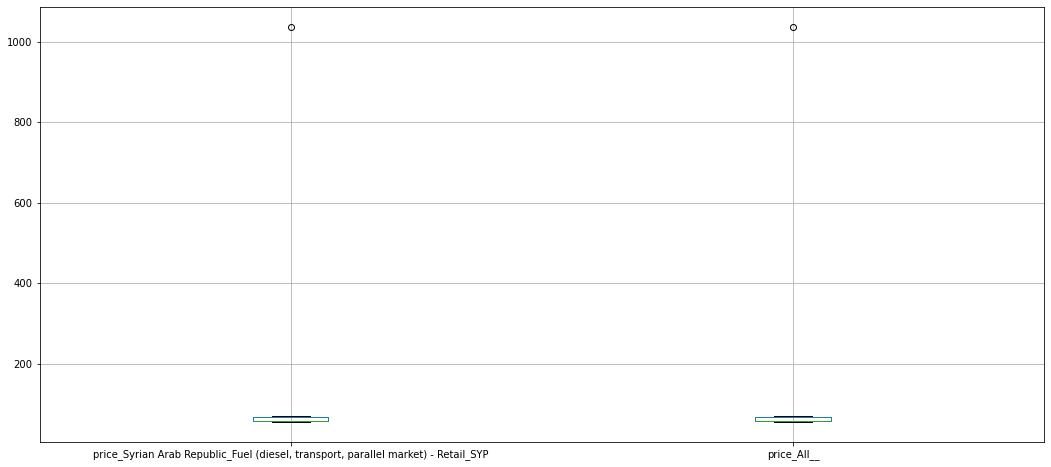

In [28]:
#βλ΄πεουμε οτι το νομισμα αλλοιωνει πολύ τα δεδομένα μας
table1.boxplot(figsize=[18,8])

12.1 Χρησιμοποιω 2 τρόπους να δω τα normalisatuion: a)min/max  b) STD

In [104]:
#std
normalized_table1=((table1-table1.mean())/table1.std())

<AxesSubplot:>

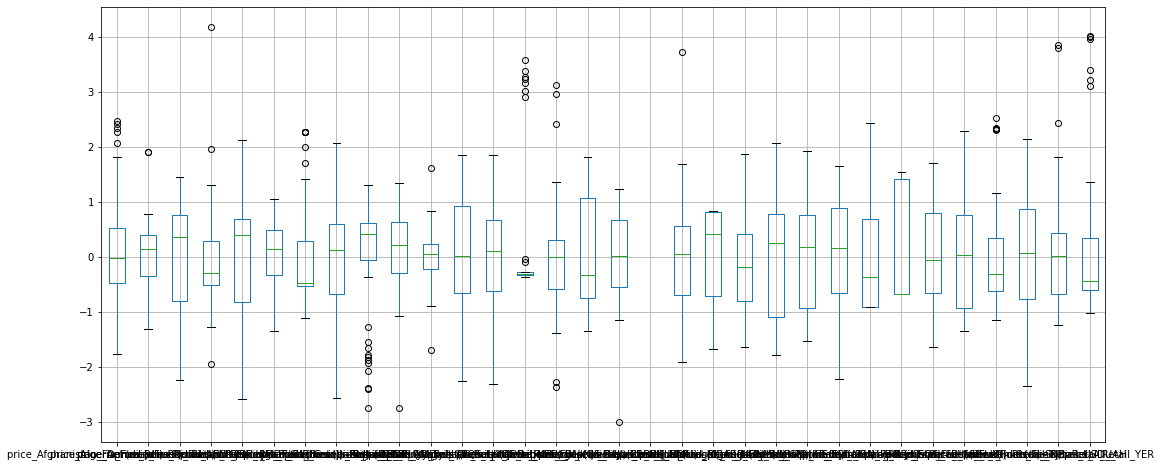

In [88]:
normalized_table1.boxplot(figsize=[18,8])

In [21]:
#min/max
normalized_table1=((table1-table1.min())/(table1.max()-table1.min()))

<AxesSubplot:>

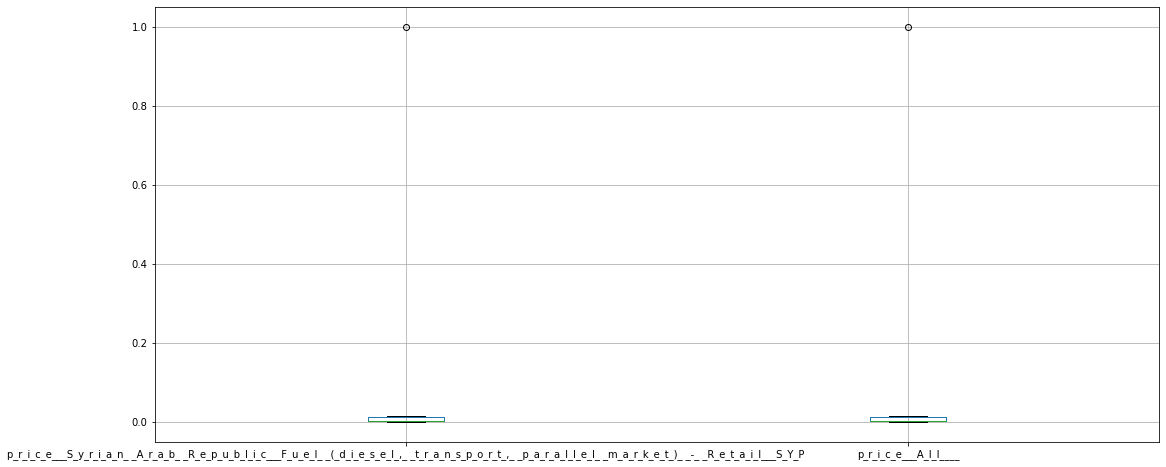

In [22]:
normalized_table1.boxplot(figsize=[18,8])

In [84]:
#ενναλακτικά μπορούμε να τρέξουμε:
#def normalize(df):
#    result = df.copy()
#    for feature_name in df.columns:
#        max_value = df[feature_name].max()
#        min_value = df[feature_name].min()
#        result[feature_name] = (df[feature_name] - min_value) / (max_value - min_value)
#    return result

In [ ]:
# η εικονα του normalise μεταξυ min/max και std είναι πολύ διαφορετική

12.2  Συγκρίνω 1 χωρα να δω αν μου έχει αλλοιώσει τις τιμες το normalisation με τα δεδομένα τουα αρχικού dataset

In [23]:
#normalised data
normalized_table1['price_Afghanistan_Fuel (diesel) - Retail_AFN'].plot.line(figsize=(15,10))

KeyError: 'price_Afghanistan_Fuel (diesel) - Retail_AFN'

In [130]:
#αρχικά δεδομένα
table = pd.pivot_table(f[(f['year']>2010)&(f['commodity']=='Fuel (diesel) - Retail')&(f['country']=='Afghanistan') ], values=['price'], index=['myDt'],columns=['country'], aggfunc=np.mean,margins=True,dropna=True)

<AxesSubplot:xlabel='myDt'>

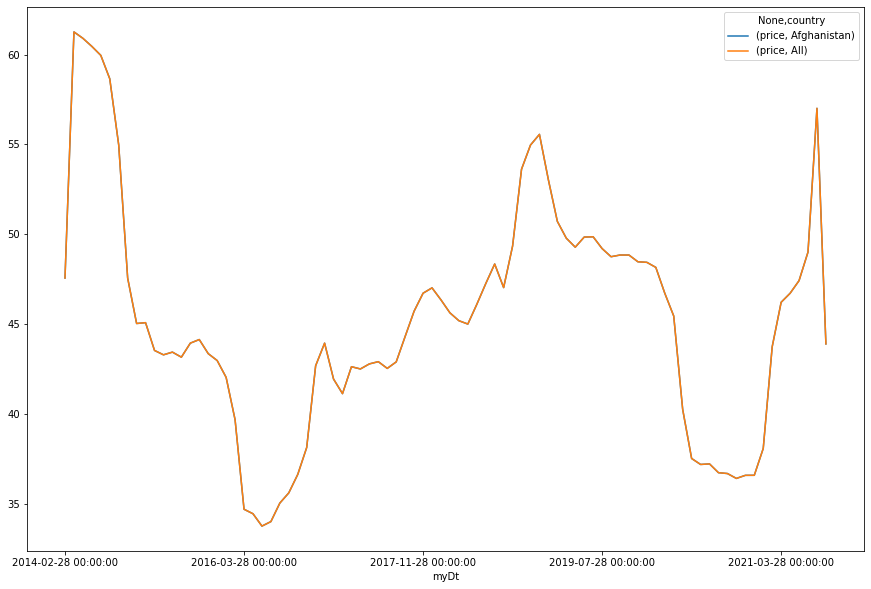

In [131]:
table.plot.line(figsize=(15,10))

In [120]:
#μια άλλη ιδέα ειναι να βρώ το ΔΧ=(χ2-χ1)/χ1
#επεισης δεν ξερω αν τα nan επιρρε΄άζουν τα δεδομένα μας (δλδ μεσο ορο καθε χωρας ανα μήνα

In [15]:
normalized_table1.plot.

NameError: name 'normalized_table1' is not defined